In [ ]:
#Очень интересное название задачи, кажется преподаватель что-то подозревает...

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#Параметры модели
states = ['E', '5', 'I']
obs_symbols = ['A', 'C', 'G', 'T']

pi = np.log([1.0, 0.0, 0.0])

#Матрица переходов A[i][j]
A = np.log([
    [0.9, 0.1, 0.0],
    [0.0, 0.0, 1.0],
    [0.0, 0.0, 0.9]
])

#Матрица эмиссий B[i][o]
B = np.log([
    [0.25, 0.25, 0.25, 0.25],
    [0.05, 0.0,  0.95, 0.0 ],
    [0.4,  0.1,  0.1,  0.4 ]])

def obs_idx(o):
    return obs_symbols.index(o)

#Витерби
def viterbi(obs):
    T = len(obs)
    N = len(states)
    delta = np.full((N, T), -np.inf)
    psi   = np.zeros((N, T), dtype=int)

    for i in range(N):
        delta[i, 0] = pi[i] + B[i, obs_idx(obs[0])]

    for t in range(1, T):
            scores = delta[:, t-1] + A[:, j]
            psi[j, t] = np.argmax(scores)
            delta[j, t] = scores[psi[j, t]] + B[j, obs_idx(obs[t])]

    path = [np.argmax(delta[:, -1])]
    for t in range(T-1, 0, -1):
        path.insert(0, psi[path[0], t])

    return [states[i] for i in path], np.max(delta[:, -1])

#Forward
def forward(obs):
    T = len(obs)
    N = len(states)
    alpha = np.full((N, T), -np.inf)

    for i in range(N):
        alpha[i, 0] = pi[i] + B[i, obs_idx(obs[0])]

    for t in range(1, T):
        for j in range(N):
            scores = alpha[:, t-1] + A[:, j]
            alpha[j, t] = np.logaddexp.reduce(scores) + B[j, obs_idx(obs[t])]

    log_prob = np.logaddexp.reduce(alpha[:, -1])
    return alpha, log_prob

#Backward
def backward(obs):
    T = len(obs)
    N = len(states)
    beta = np.full((N, T), -np.inf)

    beta[:, -1] = 0.0

    for t in range(T-2, -1, -1):
        for i in range(N):
            scores = A[i, :] + B[:, obs_idx(obs[t+1])] + beta[:, t+1]
            beta[i, t] = np.logaddexp.reduce(scores)

    return beta

#Апостериорное декодирование
def posterior(obs):
    alpha, log_prob = forward(obs)
    beta = backward(obs)
    log_gamma = alpha + beta - log_prob
    gamma = np.exp(log_gamma)
    return gamma



/tmp/ipykernel_10566/3163440479.py:8: RuntimeWarning: divide by zero encountered in log
  pi = np.log([1.0, 0.0, 0.0])
/tmp/ipykernel_10566/3163440479.py:11: RuntimeWarning: divide by zero encountered in log
  A = np.log([
/tmp/ipykernel_10566/3163440479.py:18: RuntimeWarning: divide by zero encountered in log
  B = np.log([


/tmp/ipykernel_10566/1903389304.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(seq), fontsize=8)
/tmp/ipykernel_10566/1903389304.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(seq), fontsize=8)
/tmp/ipykernel_10566/1903389304.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(seq), fontsize=8)


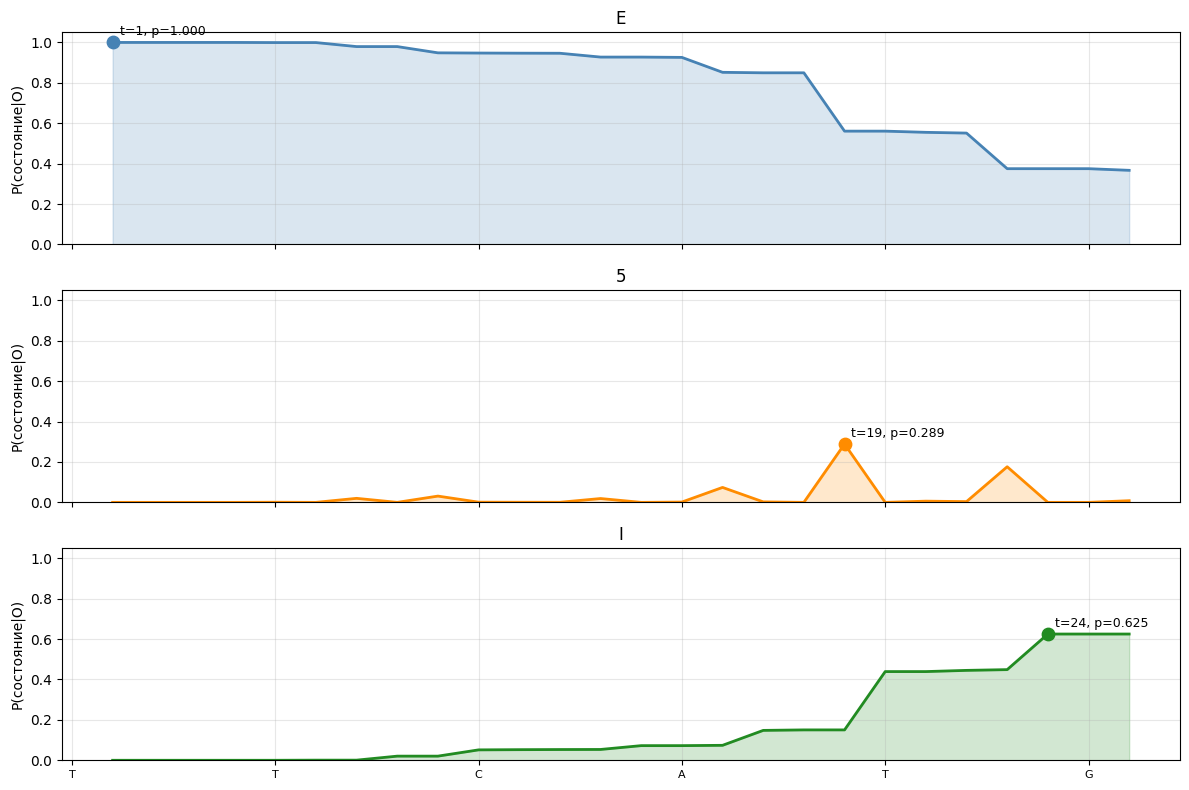

In [3]:
seq = list("CTTCATGTGAAAGCAGACGTAAGTCA")

gamma = posterior(seq)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
colors = ['steelblue', 'darkorange', 'forestgreen']
titles = ['E', '5', 'I']

for idx, (ax, title, color) in enumerate(zip(axes, titles, colors)):
    ax.plot(range(1, 27), gamma[idx], color=color, linewidth=2)
    ax.fill_between(range(1, 27), gamma[idx], alpha=0.2, color=color)

    t_max = np.argmax(gamma[idx]) + 1
    v_max = gamma[idx].max()
    ax.scatter(t_max, v_max, color=color, zorder=5, s=80)
    ax.annotate(f't={t_max}, p={v_max:.3f}', (t_max, v_max),
                textcoords="offset points", xytext=(5, 5), fontsize=9)

    ax.set_title(title)
    ax.set_ylabel('P(состояние|O)')
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

    ax.set_xticklabels(list(seq), fontsize=8)

plt.tight_layout()
plt.savefig('posterior_probs.png', dpi=150, bbox_inches='tight')
plt.show()